In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")
print("Libraries imported")

Libraries imported


In [2]:
Housing_data = pd.read_csv(r"C:\Users\hp\Downloads\ML\Housing.csv")

In [3]:
Housing_data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
Housing_data.shape

(545, 13)

In [5]:
Housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
Housing_data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
Housing_data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
Housing_data['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

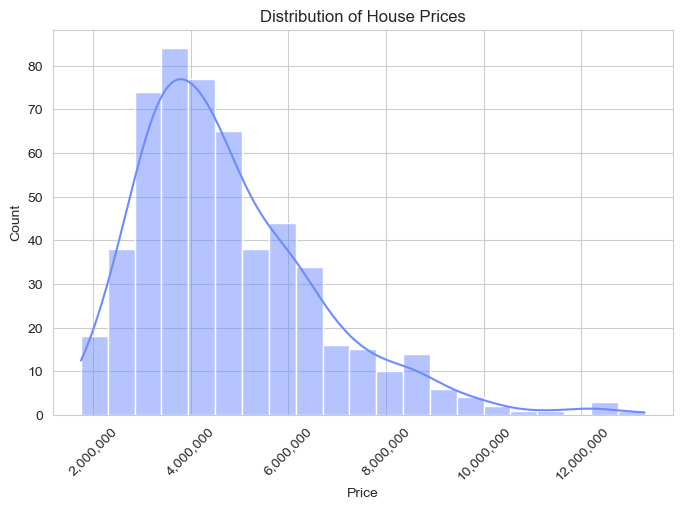

In [9]:
import matplotlib.ticker as ticker

plt.figure(figsize=(8,5))
sns.histplot(Housing_data["price"], kde=True, color="#6c8bff")

plt.gca().xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.xticks(rotation=45)
plt.show()


In [10]:
Housing_data = pd.get_dummies(
    Housing_data,
    columns=[
        'mainroad',
        'guestroom',
        'basement',
        'hotwaterheating',
        'airconditioning',
        'prefarea',
        'furnishingstatus'
    ],
    drop_first=True
)

In [18]:
Housing_data.head(10)

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False
5,10850000,7500,3,3,1,2,True,False,True,False,True,True,True,False
6,10150000,8580,4,3,4,2,True,False,False,False,True,True,True,False
7,10150000,16200,5,3,2,0,True,False,False,False,False,False,False,True
8,9870000,8100,4,1,2,2,True,True,True,False,True,True,False,False
9,9800000,5750,3,2,4,1,True,True,False,False,True,True,False,True


In [11]:
x = Housing_data.drop("price", axis=1)
y = Housing_data["price"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Training rows:",x_train.shape[0])
print("Testing rows:",x_test.shape[0])

Training rows: 436
Testing rows: 109


In [12]:
numeric_cols = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train[numeric_cols] = scaler.fit_transform(
    x_train[numeric_cols]
)

x_test[numeric_cols] = scaler.transform(
    x_test[numeric_cols]
)


In [14]:
model = LinearRegression()
model.fit(x_train, y_train)
print("Model trained")

Model trained


In [15]:
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
mae=mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
    
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print(f"R2 Score: {r2*100:.2f}%")


MAE: 970043.4039201641
MSE: 1754318687330.668
RMSE: 1324506.9600914402
R2 Score: 65.29%


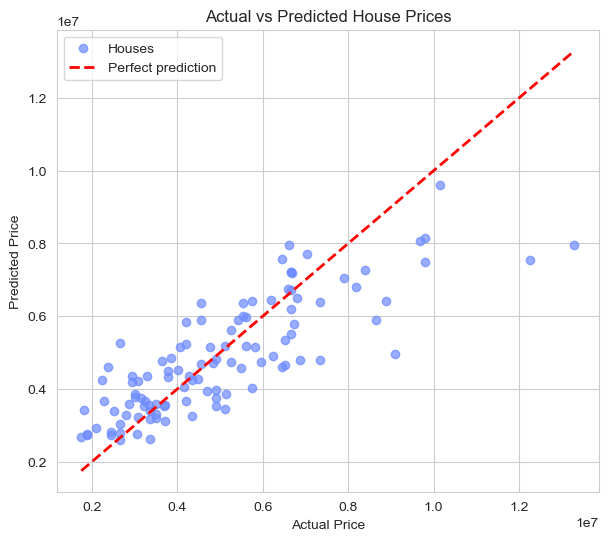

In [16]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred,
            color="#6c8bff",
            alpha=0.7,
            label="Houses")

lims = [y_test.min(), y_test.max()]

plt.plot(lims, lims,
         "r--",
         linewidth=2,
         label="Perfect prediction")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.legend()
plt.show()

In [17]:
import pandas as pd
area = float(input("Enter area of house: "))
bedrooms = int(input("Enter number of bedrooms: "))
bathrooms = int(input("Enter number of bathrooms: "))
stories = int(input("Enter number of stories: "))
parking = int(input("Enter parking spaces: "))
mainroad = input("Is it on main road? (yes/no): ").lower()
guestroom = input("Has guest room? (yes/no): ").lower()
basement = input("Has basement? (yes/no): ").lower()
hotwaterheating = input("Has hot water heating? (yes/no): ").lower()
airconditioning = input("Has air conditioning? (yes/no): ").lower()
prefarea = input("Is it in preferred area? (yes/no): ").lower()
furnishingstatus = input(
    "Furnishing status (furnished/semi-furnished/unfurnished): "
).lower()

print(f"New house area: {area}")
print(f"New house bedrooms: {bedrooms}")
print(f"New house bathrooms: {bathrooms}")
print(f"New house stories: {stories}")
print(f"New house parking: {parking}")
print(f"New house mainroad: {mainroad}")
print(f"New house guestroom: {guestroom}")
print(f"New house basement: {basement}")
print(f"New house hotwaterheating: {hotwaterheating}")
print(f"New house airconditioning: {airconditioning}")
print(f"New house prefarea: {prefarea}")
print(f"New house furnishingstatus: {furnishingstatus}")


new_house = pd.DataFrame({
    'area': [area],
    'bedrooms': [bedrooms],
    'bathrooms': [bathrooms],
    'stories': [stories],
    'parking': [parking],
    'mainroad_yes': [1 if mainroad == "yes" else 0],
    'guestroom_yes': [1 if guestroom == "yes" else 0],
    'basement_yes': [1 if basement == "yes" else 0],
    'hotwaterheating_yes': [1 if hotwaterheating == "yes" else 0],
    'airconditioning_yes': [1 if airconditioning == "yes" else 0],
    'prefarea_yes': [1 if prefarea == "yes" else 0],
        'furnishingstatus_semi-furnished': [
        1 if furnishingstatus == "semi-furnished" else 0
    ],
    'furnishingstatus_unfurnished': [
        1 if furnishingstatus == "unfurnished" else 0
    ]
})

new_house = new_house[x_train.columns]
new_house[numeric_cols] = scaler.transform(
    new_house[numeric_cols]
)

prediction = model.predict(new_house)
print(f"Predicted House Price: {prediction[0]:,.2f}")


New house area: 1200.0
New house bedrooms: 3
New house bathrooms: 4
New house stories: 2
New house parking: 1
New house mainroad: yes
New house guestroom: no
New house basement: yes
New house hotwaterheating: yes
New house airconditioning: yes
New house prefarea: yes
New house furnishingstatus: semi-furnished
Predicted House Price: 8,928,361.77
